In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [2]:
import pandas as pd 
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.preprocessing import StandardScaler


In [3]:
train=pd.read_csv('../input/digit-recognizer/train.csv')
test=pd.read_csv('../input/digit-recognizer/test.csv')
sample=pd.read_csv('../input/digit-recognizer/sample_submission.csv')

In [4]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Do We have Enough Data for Each number ?**

<AxesSubplot:>

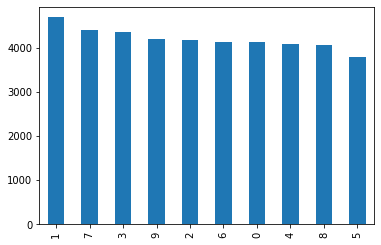

In [5]:
train.label.value_counts().plot.bar()

**lets plot random number**

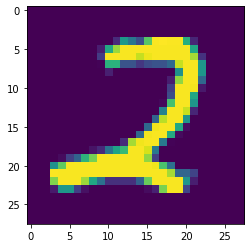

In [6]:
im=np.reshape(train.iloc[np.random.randint(0,train.shape[0]),1:].values,(28,28))
from matplotlib import pyplot as plt
plt.imshow(im)

**lest look at the statistics ...**

In [7]:
print(train.describe().T.sort_values(by='std' , ascending=False))

            count        mean         std  min  25%    50%    75%    max
pixel406  42000.0  130.140143  113.850143  0.0  0.0  144.0  253.0  255.0
pixel378  42000.0  111.459333  113.712467  0.0  0.0   64.0  252.0  255.0
pixel627  42000.0  113.002857  112.996674  0.0  0.0   79.0  252.0  255.0
pixel461  42000.0  115.358738  112.917172  0.0  0.0   87.0  252.0  255.0
pixel434  42000.0  135.521643  112.749757  0.0  0.0  167.0  253.0  255.0
...           ...         ...         ...  ...  ...    ...    ...    ...
pixel83   42000.0    0.000000    0.000000  0.0  0.0    0.0    0.0    0.0
pixel84   42000.0    0.000000    0.000000  0.0  0.0    0.0    0.0    0.0
pixel85   42000.0    0.000000    0.000000  0.0  0.0    0.0    0.0    0.0
pixel111  42000.0    0.000000    0.000000  0.0  0.0    0.0    0.0    0.0
pixel783  42000.0    0.000000    0.000000  0.0  0.0    0.0    0.0    0.0

[785 rows x 8 columns]


**Do We have null values ?******

In [8]:
train.isna().sum().values.sum()

0

**Scale the Data**

In [9]:

train.iloc[:,1:]=(train.iloc[:,1:])/255
test=test/255


In [10]:
print(train.describe().T.sort_values(by='std' , ascending=False))

            count      mean       std  min  25%       50%       75%  max
label     42000.0  4.456643  2.887730  0.0  2.0  4.000000  7.000000  9.0
pixel406  42000.0  0.510354  0.446471  0.0  0.0  0.564706  0.992157  1.0
pixel378  42000.0  0.437095  0.445931  0.0  0.0  0.250980  0.988235  1.0
pixel627  42000.0  0.443148  0.443124  0.0  0.0  0.309804  0.988235  1.0
pixel461  42000.0  0.452387  0.442812  0.0  0.0  0.341176  0.988235  1.0
...           ...       ...       ...  ...  ...       ...       ...  ...
pixel83   42000.0  0.000000  0.000000  0.0  0.0  0.000000  0.000000  0.0
pixel84   42000.0  0.000000  0.000000  0.0  0.0  0.000000  0.000000  0.0
pixel85   42000.0  0.000000  0.000000  0.0  0.0  0.000000  0.000000  0.0
pixel111  42000.0  0.000000  0.000000  0.0  0.0  0.000000  0.000000  0.0
pixel783  42000.0  0.000000  0.000000  0.0  0.0  0.000000  0.000000  0.0

[785 rows x 8 columns]


# SVM_model

In [11]:
X=train.drop(['label'] , axis=1)
y=train['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33,shuffle=True, random_state=42)

In [12]:
svm_model=svm.SVC(kernel='poly')
svm_model.fit(X_train,y_train)
y_pred=svm_model.predict(X_test)
report=classification_report(y_true=y_test,y_pred=y_pred)
print(report)   

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1333
           1       0.96      0.99      0.98      1520
           2       0.98      0.96      0.97      1414
           3       0.97      0.95      0.96      1471
           4       0.97      0.97      0.97      1358
           5       0.95      0.97      0.96      1205
           6       0.98      0.98      0.98      1397
           7       0.97      0.97      0.97      1480
           8       0.97      0.96      0.97      1334
           9       0.96      0.95      0.96      1348

    accuracy                           0.97     13860
   macro avg       0.97      0.97      0.97     13860
weighted avg       0.97      0.97      0.97     13860



In [13]:
y_pred_final=svm_model.predict(test)
sample['Label']=y_pred_final
sample.to_csv('submission_SVM.csv', index=False)

# Keras_model

In [14]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.utils.np_utils import to_categorical

In [15]:
X=train.drop(['label'] , axis=1)
y=train['label']

In [16]:
X=X.values.reshape(-1,28,28,1)
test=test.values.reshape(-1,28,28,1)

In [17]:
y=to_categorical(y,num_classes=10)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,shuffle=True, random_state=42)

In [19]:
input_shape = (28, 28, 1)
batch_size = 128
num_classes = 10
epochs = 10

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',input_shape=input_shape))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,optimizer='adam',metrics=['accuracy'])

2022-05-18 08:15:07.227760: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [20]:
hist = model.fit(X_train, y_train,batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(X_test, y_test))
print("The model has successfully trained")

model.save('mnist.h5')
print("Saving the model as mnist.h5")

2022-05-18 08:15:07.653820: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/10
263/263 [==============================] - 35s 130ms/step - loss: 0.2786 - accuracy: 0.9132 - val_loss: 0.0786 - val_accuracy: 0.9774
Epoch 2/10
263/263 [==============================] - 34s 128ms/step - loss: 0.0832 - accuracy: 0.9745 - val_loss: 0.0549 - val_accuracy: 0.9824
Epoch 3/10
263/263 [==============================] - 34s 128ms/step - loss: 0.0593 - accuracy: 0.9814 - val_loss: 0.0479 - val_accuracy: 0.9844
Epoch 4/10
263/263 [==============================] - 34s 128ms/step - loss: 0.0486 - accuracy: 0.9859 - val_loss: 0.0332 - val_accuracy: 0.9888
Epoch 5/10
263/263 [==============================] - 34s 129ms/step - loss: 0.0374 - accuracy: 0.9881 - val_loss: 0.0348 - val_accuracy: 0.9890
Epoch 6/10
263/263 [==============================] - 34s 129ms/step - loss: 0.0325 - accuracy: 0.9898 - val_loss: 0.0326 - val_accuracy: 0.9894
Epoch 7/10
263/263 [==============================] - 34s 129ms/step - loss: 0.0259 - accuracy: 0.9918 - val_loss: 0.0322 - val_ac

In [21]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.03217647597193718
Test accuracy: 0.9902380704879761


In [22]:
results = model.predict(test)

In [23]:
results = np.argmax(results,axis = 1)

In [24]:
sample['Label']=results
sample.to_csv('submission_keras.csv', index=False)